# Save figures for publication
Author: Pia Rautenstrauch

Date: 2025-04-03

## Requirements
- [x] Fontsize: >= 7
- [x] font: Arial
- [x] dpi: 600


## Other modifications
- [x] random order of plotting of colors in umap (https://github.com/scverse/scanpy/issues/891)

- run on maxg21
- conda env: scib_metrics


In [1]:
# Imports
import os
import anndata as ad
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import scib
import scanpy as sc
import seaborn as sns
from sklearn.metrics import silhouette_score, silhouette_samples
from matplotlib import rc

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
scib.__version__

'1.1.5'

In [4]:
# From https://matplotlib.org/stable/gallery/subplots_axes_and_figures/figure_size_units.html
mm = 1/25.4  # millimeters in inches

In [5]:
sc.set_figure_params(dpi_save=600, dpi=80, transparent=True, format='png', fontsize=7, figsize=(25*mm, 1.2*2/3*25*mm))

In [6]:
plt.rcParams['figure.figsize']

[0.984251968503937, 0.7874015748031495]

In [7]:
# overwrite scanpy/matplotlib default font: chose: Arial

In [8]:
# Need to remove chached fonts

In [9]:
! rm ~/.cache/matplotlib -rf

In [10]:
font_dirs = ["/fast/AG_Ohler/prauten/conda_envs/scib_metrics/fonts"]  # The path to the custom font file.
font_files = fm.findSystemFonts(fontpaths=font_dirs)

for font_file in font_files:
    fm.fontManager.addfont(font_file)

In [11]:
# change font
plt.rcParams['font.family'] = "sans-serif"
plt.rcParams['font.sans-serif'] = "Arial"

In [12]:
plt.rcParams['lines.markersize'] = 3.0

In [13]:
scenarios = ['integration_hbca', 'noIntegration_hbca', 'naiveIntegration_donor_id_hbca']

In [14]:
embedding =  ad.read_h5ad("./../../embeddings/{}.embedding.h5ad".format(scenarios[0]))

In [15]:
# color blind friendly colors

In [16]:
simplified_donor_ids = dict(zip(embedding.obs['donor_id'].unique(), ['pool_' + str(i) for i in range(1,17)]))
embedding.obs['simplified_donor_id'] = embedding.obs['donor_id'].map(simplified_donor_ids)

In [17]:
embedding.obs['simplified_donor_id'].unique()

['pool_1', 'pool_2', 'pool_3', 'pool_4', 'pool_5', ..., 'pool_12', 'pool_13', 'pool_14', 'pool_15', 'pool_16']
Length: 16
Categories (16, object): ['pool_6', 'pool_15', 'pool_8', 'pool_1', ..., 'pool_5', 'pool_14', 'pool_2', 'pool_7']

In [18]:
import seaborn as sns

# Generate a larger palette using Seaborn
colorblind_friendly_palette = sns.color_palette("colorblind", n_colors=10)
large_palette = sns.color_palette("tab20b", n_colors=16)


In [19]:
colorblind_friendly_palette

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [20]:
large_palette

[(0.2235294117647059, 0.23137254901960785, 0.4745098039215686),
 (0.3215686274509804, 0.32941176470588235, 0.6392156862745098),
 (0.4196078431372549, 0.43137254901960786, 0.8117647058823529),
 (0.611764705882353, 0.6196078431372549, 0.8705882352941177),
 (0.38823529411764707, 0.4745098039215686, 0.2235294117647059),
 (0.5490196078431373, 0.6352941176470588, 0.3215686274509804),
 (0.7098039215686275, 0.8117647058823529, 0.4196078431372549),
 (0.807843137254902, 0.8588235294117647, 0.611764705882353),
 (0.5490196078431373, 0.42745098039215684, 0.19215686274509805),
 (0.7411764705882353, 0.6196078431372549, 0.2235294117647059),
 (0.9058823529411765, 0.7294117647058823, 0.3215686274509804),
 (0.9058823529411765, 0.796078431372549, 0.5803921568627451),
 (0.5176470588235295, 0.23529411764705882, 0.2235294117647059),
 (0.6784313725490196, 0.28627450980392155, 0.2901960784313726),
 (0.8392156862745098, 0.3803921568627451, 0.4196078431372549),
 (0.9058823529411765, 0.5882352941176471, 0.611764705882353)]

In [21]:
palette = dict(zip(embedding.obs['author_cell_type'].unique().tolist() + embedding.obs['simplified_donor_id'].unique().tolist(), colorblind_friendly_palette + large_palette))

In [22]:
import matplotlib as mpl
mpl.rcParams["image.cmap"]

'viridis'

In [23]:
mpl.rcParams['axes.prop_cycle']

'#1f77b4'
'#ff7f0e'
'#279e68'
'#d62728'
'#aa40fc'
'#8c564b'
'#e377c2'
'#b5bd61'
'#17becf'
'#aec7e8'
'#ffbb78'


In [24]:
def plot_umaps(models):
    np.random.seed(61)

    # Collect computed scores, nested dict is simple to convert to pd.DataFrame
    for model in models:
        # Load data
        embedding =  ad.read_h5ad("./../../embeddings/{}.embedding.h5ad".format(model))
        
        # Read embeddings
        embedding.obsm['X_emb'] = embedding.X

        # Compute neighbors 
        sc.pp.neighbors(embedding, use_rep='X_emb')
        sc.tl.umap(embedding)

        # make sure these variables are categorical

        simplified_donor_ids = dict(zip(embedding.obs['donor_id'].unique(), ['pool_' + str(i) for i in range(1,17)]))
        embedding.obs['simplified_donor_id'] = embedding.obs['donor_id'].map(simplified_donor_ids)
        embedding.obs['sample'] = embedding.obs['simplified_donor_id'].astype('category')

        # make sure these cell type is categorical
        embedding.obs['cell_type'] = embedding.obs['author_cell_type'].astype('category')

        # random plotting order
        embedding = sc.pp.subsample(embedding, fraction=1., copy=True)

        ### Save UMAP visualization as png 
        sc.pl.umap(
            embedding,
            color=['cell_type', 'sample'],
            size=0.3,
            frameon=False,
            ncols=1,
            wspace=-0.2,
            palette=palette,
            save="_{}.png".format(model),
            legend_loc=None,
            title=['','']
            #legend_fontsize='x-small'
        )

    ### Save UMAP visualization as png 
    sc.pl.umap(
            embedding,
            color=['cell_type', 'sample'],
            size=0.3,
            frameon=False,
            ncols=1,
            wspace=-0.2,
            palette=palette,
            save="_{}_legend.png".format(model),
            legend_fontsize='xx-small',
            title=['','']
    )


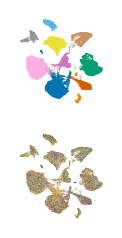

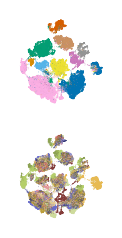

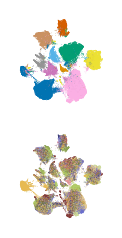

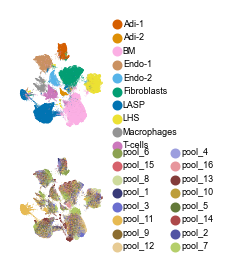

In [25]:
plot_umaps(scenarios)

In [26]:
import matplotlib as mpl

font_settings = {key: value for key, value in mpl.rcParams.items() if 'font' in key.lower()}
for key, value in font_settings.items():
    print(f"{key}: {value}")


font.cursive: ['Apple Chancery', 'Textile', 'Zapf Chancery', 'Sand', 'Script MT', 'Felipa', 'Comic Neue', 'Comic Sans MS', 'cursive']
font.family: ['sans-serif']
font.fantasy: ['Chicago', 'Charcoal', 'Impact', 'Western', 'xkcd script', 'fantasy']
font.monospace: ['DejaVu Sans Mono', 'Bitstream Vera Sans Mono', 'Computer Modern Typewriter', 'Andale Mono', 'Nimbus Mono L', 'Courier New', 'Courier', 'Fixed', 'Terminal', 'monospace']
font.sans-serif: ['Arial']
font.serif: ['DejaVu Serif', 'Bitstream Vera Serif', 'Computer Modern Roman', 'New Century Schoolbook', 'Century Schoolbook L', 'Utopia', 'ITC Bookman', 'Bookman', 'Nimbus Roman No9 L', 'Times New Roman', 'Times', 'Palatino', 'Charter', 'serif']
font.size: 7.0
font.stretch: normal
font.style: normal
font.variant: normal
font.weight: normal
legend.fontsize: 6.44
legend.title_fontsize: 18.0
mathtext.fontset: dejavusans
pdf.fonttype: 3
pdf.use14corefonts: False
pgf.rcfonts: True
ps.fonttype: 3
svg.fonttype: path


In [27]:
print("Default font size:", plt.rcParams['font.size'])
print("Title font size:", plt.rcParams['axes.titlesize'])
print("Axes label font size:", plt.rcParams['axes.labelsize'])
print("X-tick label font size:", plt.rcParams['xtick.labelsize'])
print("Y-tick label font size:", plt.rcParams['ytick.labelsize'])
print("Legend font size:", plt.rcParams['legend.fontsize'])


Default font size: 7.0
Title font size: 7.0
Axes label font size: 7.0
X-tick label font size: 7.0
Y-tick label font size: 7.0
Legend font size: 6.44
